# PV feed-in and grid draw in example district scenarios

This notebook investigates example district scenarios and their **hourly PV production and grid interaction**.

The purpose is to assess the potential strain on the electricity grid from **PV feed-in**, and to compare it with the **grid draw** expected in the same district scenarios. The analysis focuses on:

- annual PV self-consumption and self-sufficiency indicators,
- hourly magnitude and seasonal timing of grid draw and PV feed-in,
- peak power,
- and the duration of high feed-in and grid-draw events.

Each Excel file is a single-scenario PEExcel timestep export (`IN.STAGE`, `OUT.Live`, `SIM2`). PEXL loads all files and combines their scenarios into one `Project`.

In [1]:
from pathlib import Path

import pandas as pd
import pexl

# Directory containing the single-scenario timestep exports.
folder = Path(r"C:\Users\schneids\OneDrive\Documents")
file_pattern = "Aspern PVCheck*.xlsx"

# Detailed view of the first hours of each duration curve.
zoom_hours = 100

flow_colors = {
    "Grid draw": "firebrick",
    "PV feed-in": "forestgreen",
}

## Load all timestep scenarios

`Project.from_files()` combines the scenarios from the individual export files into one project. Scenario identity is retained by PEXL, while each scenario also carries its own hourly timestep data.

In [2]:
files = [
    file
    for file in sorted(folder.glob(file_pattern))
    if not file.name.startswith("~$")
]

if not files:
    raise FileNotFoundError(
        f"No files matching {file_pattern!r} found in {folder}"
    )
files


[WindowsPath('C:/Users/schneids/OneDrive/Documents/Aspern PVCheck _ E7A.xlsx'),
 WindowsPath('C:/Users/schneids/OneDrive/Documents/Aspern PVCheck _ F10.xlsx'),
 WindowsPath('C:/Users/schneids/OneDrive/Documents/Aspern PVCheck _ F12.xlsx'),
 WindowsPath('C:/Users/schneids/OneDrive/Documents/Aspern PVCheck _ F13.xlsx'),
 WindowsPath('C:/Users/schneids/OneDrive/Documents/Aspern PVCheck _ F3.xlsx'),
 WindowsPath('C:/Users/schneids/OneDrive/Documents/Aspern PVCheck _ F5.xlsx'),
 WindowsPath('C:/Users/schneids/OneDrive/Documents/Aspern PVCheck _ F6.xlsx'),
 WindowsPath('C:/Users/schneids/OneDrive/Documents/Aspern PVCheck _ F7.xlsx'),
 WindowsPath('C:/Users/schneids/OneDrive/Documents/Aspern PVCheck _ F9B.xlsx'),
 WindowsPath('C:/Users/schneids/OneDrive/Documents/Aspern PVCheck _ H1.xlsx'),
 WindowsPath('C:/Users/schneids/OneDrive/Documents/Aspern PVCheck _ J6B.xlsx')]

In [3]:
project = pexl.Project.from_files(files)

missing_timeseries = [
    scenario.column_name
    for scenario in project
    if scenario.timeseries is None
]
if missing_timeseries:
    raise ValueError(
        f"Missing timestep data for scenarios: {missing_timeseries}"
    )

project

<Project scenarios=11 warnings=0>

## Annual PV indicators

The PEXL project view is used to select only the annual indicators relevant to PV utilization and grid feed-in. This provides a compact comparison across all scenarios without manually accessing each scenario object.

In [18]:
pv_metrics = project.out.select(
    "PV_own_consumption",
    "PV_own_consumption_flex",
    "PV_own_consumption",
    "EUI_self_sufficiency",
    "PV_peak_grid_feedin",
    "PV_peak_grid_feedin_date",
)
pv_metrics

,PV_own_consumption,PV_own_consumption_flex,EUI_self_sufficiency,PV_peak_grid_feedin,PV_peak_grid_feedin_date
column_name,,,,,
Aspern PVCheck _ E7A,0.722461,0,0.384752,458.950281,2018-06-03 10:00:18.400
Aspern PVCheck _ F10,0.495853,0,0.446116,223.901096,2018-07-14 10:00:23.320
Aspern PVCheck _ F12,0.842773,0,0.314345,130.353867,2018-07-14 10:00:23.320
Aspern PVCheck _ F13,0.739459,0,0.305827,115.143048,2018-07-14 10:00:23.320
Aspern PVCheck _ F3,0.767313,0,0.327884,162.452275,2018-07-14 10:00:23.320
Aspern PVCheck _ F5,0.663993,0,0.348075,175.447142,2018-07-14 10:00:23.320
Aspern PVCheck _ F6,0.748177,0,0.339082,170.200481,2018-07-14 10:00:23.320
Aspern PVCheck _ F7,0.675059,0,0.356353,186.444769,2018-07-14 10:00:23.320
Aspern PVCheck _ F9B,0.611304,0,0.310423,111.446153,2018-06-07 14:00:18.900


In [ ]:
# if you dont know the names, you can use the pexl glossary to find and specify them

import pexl 
pexl.glossary.GFA_total


<🏙️ GFA_total 'BGF Quartier' [m²] @IN>

In [ ]:


pv_metrics = project.out.select(
    pexl.glossary.PV_own_consumption,
    pexl.glossary.PV_own_consumption_flex,
    pexl.glossary.PV_own_consumption,
    pexl.glossary.EUI_self_sufficiency,
    pexl.glossary.PV_peak_grid_feedin,
    pexl.glossary.PV_peak_grid_feedin_date,
)
pv_metrics


## Hourly grid interaction

The exported timestep values are specific energy quantities in Wh/m² per hourly timestep. Multiplication by the scenario gross floor area (`GFA_total`) and division by 1000 converts them to kWh per hour, numerically equivalent to the mean **kW** during that hour.

Two comparable datasets are prepared for every scenario:

- **Grid draw**: electricity drawn from the grid.
- **PV feed-in**: PV electricity exported to the grid.

The same data are also arranged as a nested mapping for direct multi-scenario plotting with `pexl.plot.duration_curve()`.

In [5]:
grid_draw = {}
pv_feedin = {}
flow_data = {}

for scenario in project:
    df = scenario.timeseries
    factor = scenario.v.GFA_total / 1000

    grid = df["E_grid"] * factor
    feedin = df["PV_to_Egrid"] * factor

    grid_draw[scenario.column_name] = grid
    pv_feedin[scenario.column_name] = feedin

    flow_data[scenario.column_name] = {
        "Grid draw": grid,
        "PV feed-in": feedin,
    }

grid_draw = pd.DataFrame(grid_draw)
pv_feedin = pd.DataFrame(pv_feedin)

## Hourly and seasonal patterns

Heatmaps show **when** high grid interaction occurs during the year. Grid draw and PV feed-in are plotted separately so that each can use a suitable sequential color scale.

Text(0.5, 0.98, 'Aspern PVCheck _ F7')

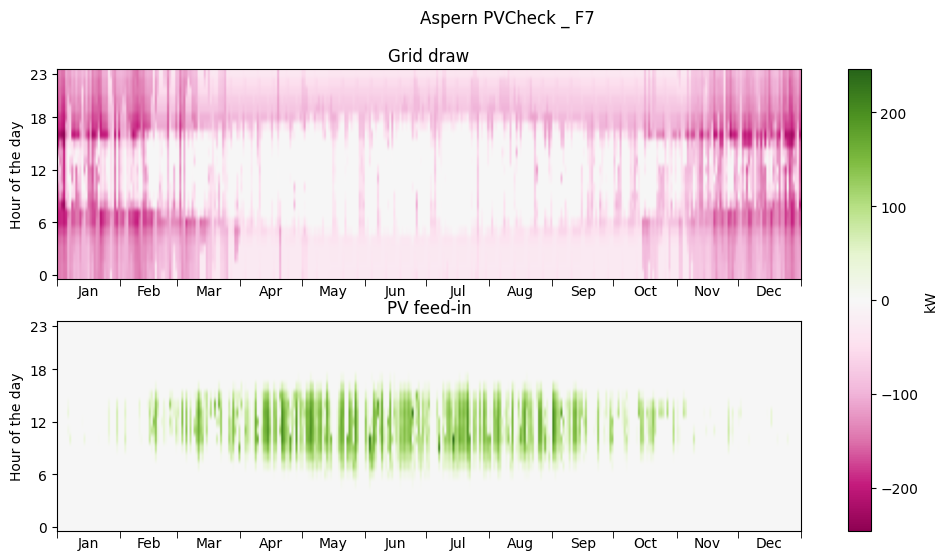

In [6]:
from matplotlib import pyplot as plt


scenario_name = "Aspern PVCheck _ F7"

scenario = project[scenario_name]
df = scenario.timeseries
factor = scenario.v.GFA_total / 1000

pexl.plot.heatmap(
    {
        "Grid draw": -df.E_grid * factor,
        "PV feed-in": df.PV_to_Egrid * factor,
    },
    unit="kW",
    layout="vertical",
    center=0,
    cmap="PiYG",
)
plt.suptitle(scenario_name)

## Duration curves: magnitude and persistence of grid strain

The annual duration curves sort all hourly values from highest to lowest. They therefore show both:

- the **magnitude** of peak grid draw and PV feed-in,
- and the **number of hours** for which high grid loads persist.

Each row represents one district scenario. The second panel zooms into the first `zoom_hours` hours so that the most grid-relevant peak events can be compared more closely.

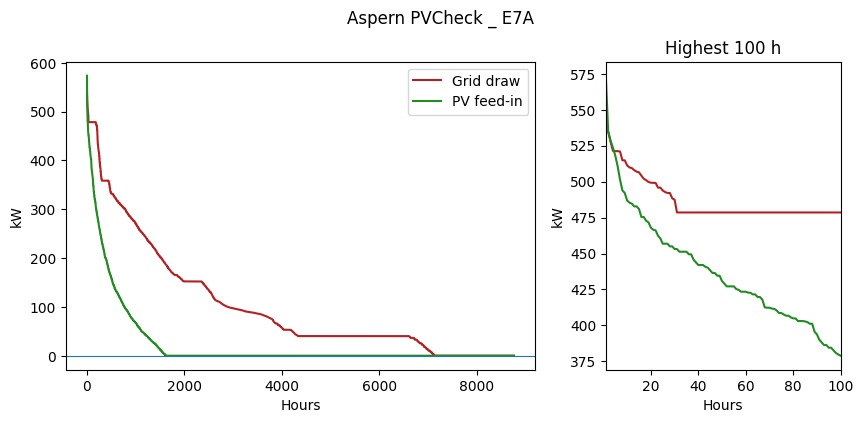

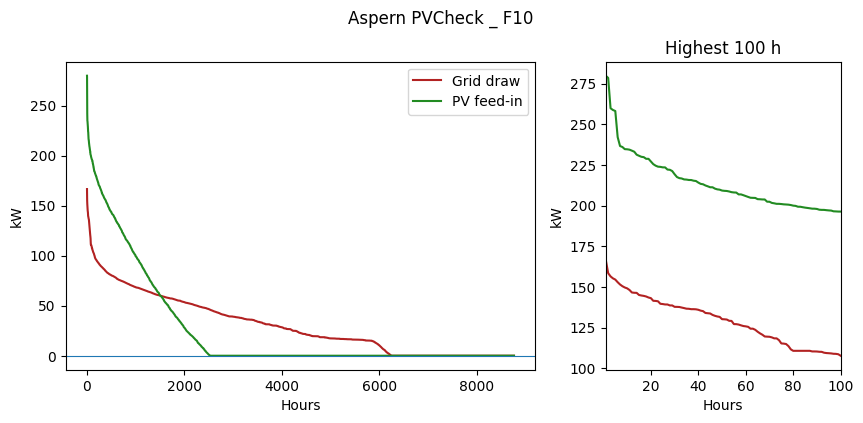

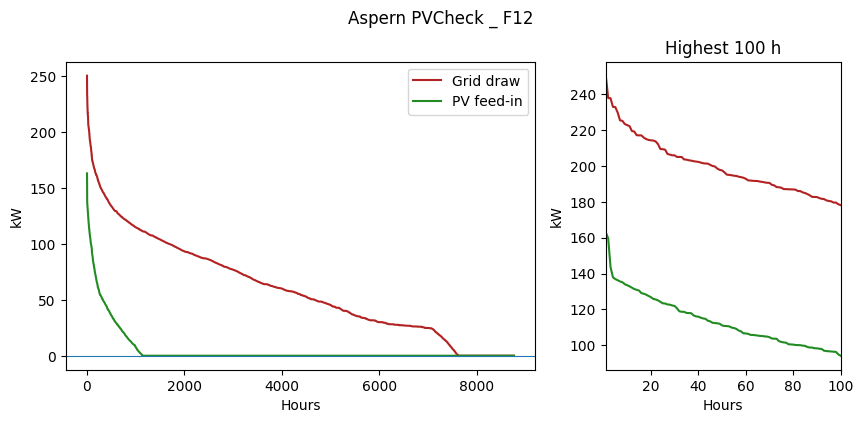

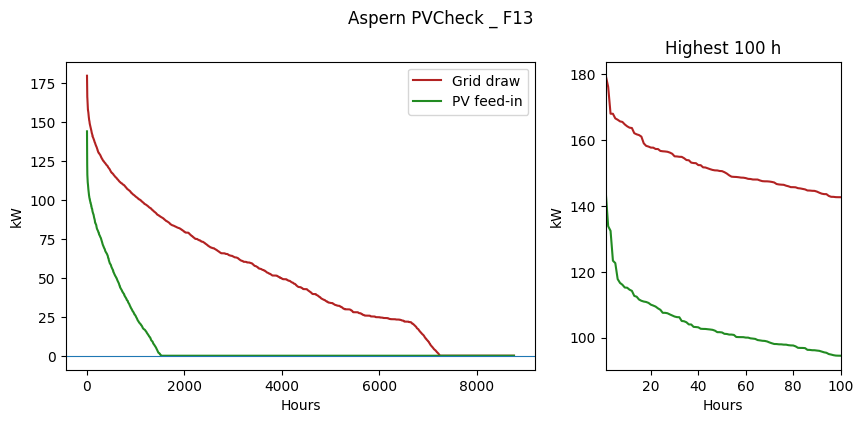

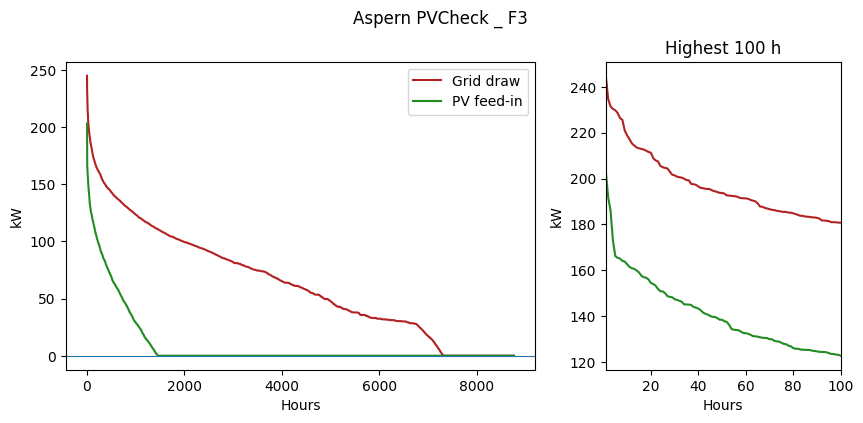

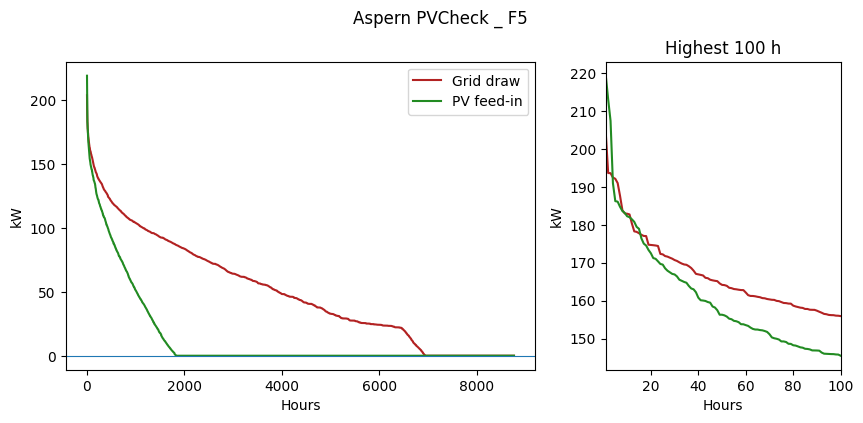

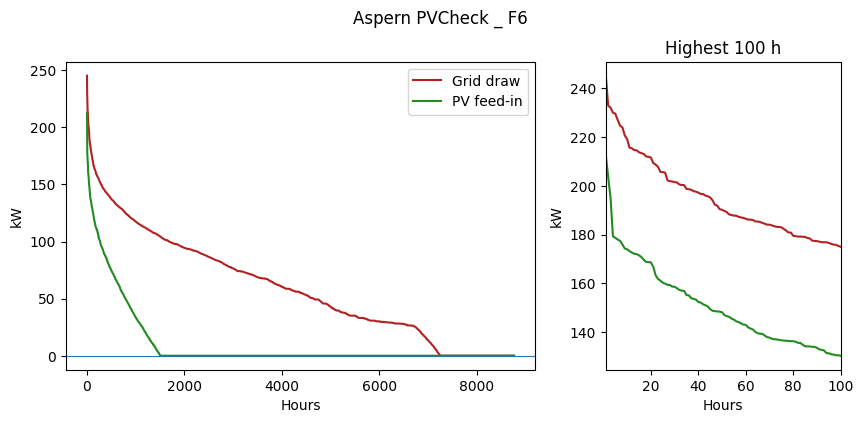

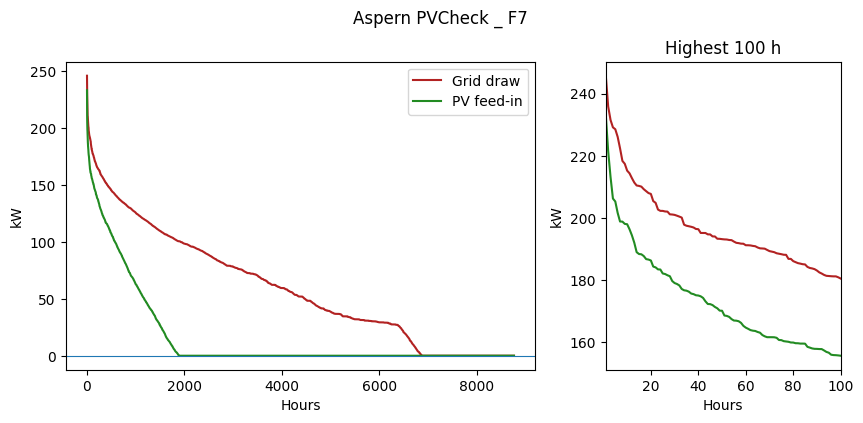

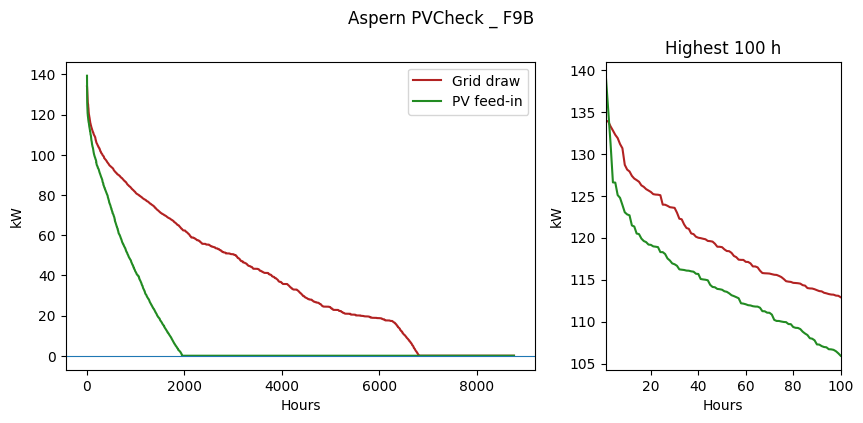

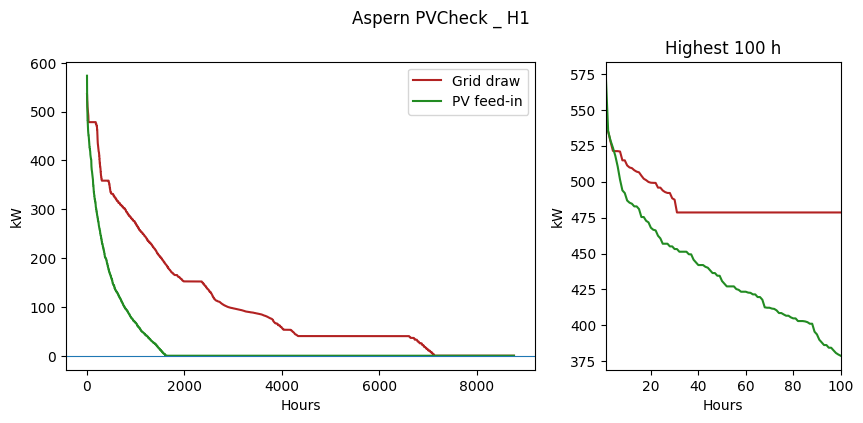

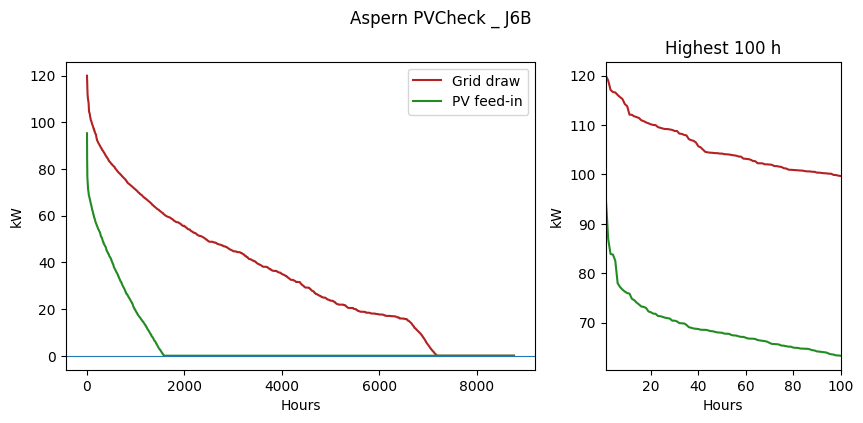

In [7]:
import matplotlib.pyplot as plt
from pathlib import Path

output_dir = Path(
    r"C:\Users\schneids\Nextcloud\EE\6_Daten\Quartiere\1220_Wien_Aspern_Seestadt\Unterlagen PV Überschüsse\PEexcel Auswertung"
)

output_dir.mkdir(parents=True, exist_ok=True)

for scenario_name, flows in flow_data.items():
    fig, axes = pexl.plot.duration_curve(
        flows,
        unit="kW",
        zoom_hours=zoom_hours,
        colors=flow_colors,
    )

    fig.suptitle(scenario_name, y=1.01)
    
    short_name = scenario_name.split(" _ ")[-1]
    filename = f"Load curve _ {short_name}.png"
    fig.savefig(output_dir / filename, dpi=300, bbox_inches="tight")

    plt.show()

## Interpretation

The heatmaps and duration curves complement the annual indicators:

- **Peak magnitude** indicates the maximum local power that may affect connection or grid-capacity requirements.
- **Duration at high power** indicates whether these peaks are isolated events or persistent operating conditions.
- **PV feed-in versus grid draw** shows whether export peaks are of a similar, smaller, or larger magnitude than the district's expected import peaks.
- **Seasonal and hourly timing** helps distinguish PV-driven daytime/summer export stress from demand-driven grid draw.

The analysis is intentionally based on hourly district energy balances. It characterizes expected grid-facing power profiles, but does not replace a detailed electrical network calculation with voltage, line-loading, transformer, or power-flow constraints.

In [8]:
from pexl import reporting
from pexl.plot import plotly


report = reporting.materialize(
    project.view,
    "primary_energy_balance",
)

fig = plotly.render(report)
fig.show()

In [9]:
# even simpler:
from pexl import reporting

reporting.chart_names()


('primary_energy_balance',
 'heat_balance',
 'final_energy_balance',
 'gwp_ee',
 'gwp_ee_detail',
 'district_gwp_ee',
 'multi_chart')

In [10]:

plotly.chart(project, "heat_balance").show(renderer="browser")

In [ ]:
import pexl
pexl.glossary.PEI_import


<PEI_import 'Primärenergie-Import' [kWhPEges./m²NGFa] @OUT>

In [14]:
scenario.v.PEI_import

53.8701427312935

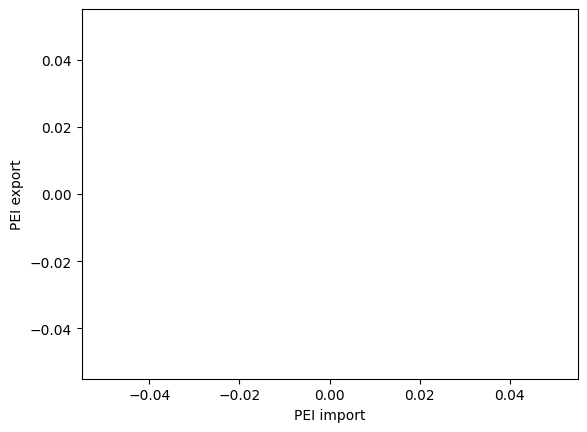

In [22]:
df = project.view.select(
    pexl.glossary.PEI_virtual_demand,
    pexl.glossary.PEI_virtual_supply,
).to_frame()

import matplotlib.pyplot as plt

plt.scatter(
    df["PEI_virtual_demand"],
    df["PEI_virtual_supply"],
)
plt.xlabel("PEI import")
plt.ylabel("PEI export")
plt.show()